# Look at the Big Picture
This data has metrics such as the population, median income, median 
housing price, and so on for each block group in California.

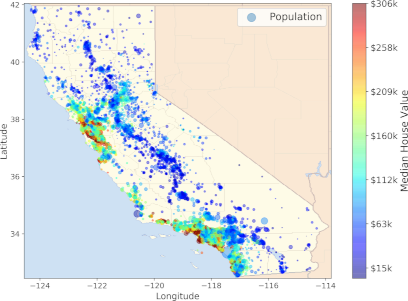

## Frame the Problem
- Understand the business objective, it will determine
  - What algorithms you will select
  - What performance measure you will use to evaluate your model
  - How much effort you should spend tweaking it
- What the current solution looks like
  - Know baseline level of performance
- Frame the Problem
  - Is it supervised/unsupervised/reinforcement learning? (supervised)
  - Is it a classification/regression task? (multivariate regression)
  - Should you use batch/online learning teniques? (batch learning)

## Select a Performance Measure
- Root Mean Square Error(L2 norm): $RMSE(\mathbf{X}, h)=\sqrt{\frac{1}{m}\sum_{i=1}^{m}(h(\mathbf{x^{(i)}})-y^{(i)})^2}$
- Mean Absolute Error: $MAE(\mathbf{X}, h)=\frac{1}{m}\sum_{i=1}^{m}|h(\mathbf{x^{(i)}})-y^{(i)}|$
- The higher the norm index, the more it focuses on large values and neglects small ones.
  - When outliers are exponentially rare (like in a bell-shaped curve), the RMSE performs very well and is generally preferred.

# Get the Data
- https://github.com/ageron/handson-ml2

## Download the Data

In [8]:
import os
import tarfile
from six.moves import urllib

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"
HOUSING_CSV = os.path.join(HOUSING_PATH, "housing.csv")

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()
    os.remove(tgz_path)
    
if not os.path.isfile(HOUSING_CSV):
    fetch_housing_data()

## Quick Look

In [12]:
import pandas as pd

def load_housing_data(housing_csv=HOUSING_CSV):
    return pd.read_csv(housing_csv)

housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [13]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [14]:
housing["ocean_proximity"].value_counts()

<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: ocean_proximity, dtype: int64

In [15]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<AxesSubplot: title={'center': 'longitude'}>,
        <AxesSubplot: title={'center': 'latitude'}>,
        <AxesSubplot: title={'center': 'housing_median_age'}>],
       [<AxesSubplot: title={'center': 'total_rooms'}>,
        <AxesSubplot: title={'center': 'total_bedrooms'}>,
        <AxesSubplot: title={'center': 'population'}>],
       [<AxesSubplot: title={'center': 'households'}>,
        <AxesSubplot: title={'center': 'median_income'}>,
        <AxesSubplot: title={'center': 'median_house_value'}>]],
      dtype=object)

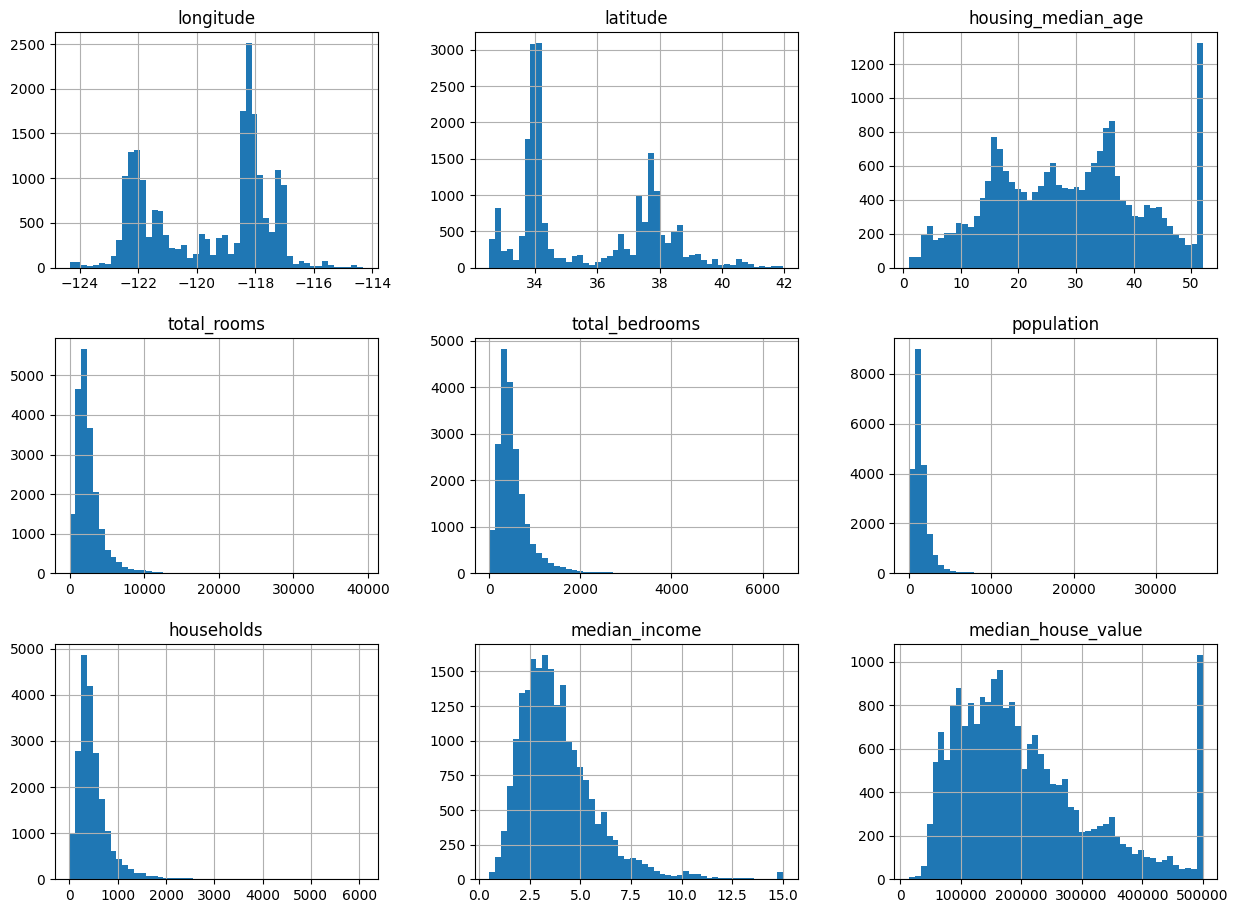

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(15,11))

## Notice:
- The median income attribute does not look like it is expressed in US dollars(USD).
  - The data has been scaled and capped at 15 for higher median incomes, and at 0.5 for lower median incomes.
  - 3 actually means about $30,000
  
- The housing median age and the median house value were also capped.
  - Since the median house value is your target attribute, ML algorithms may learn that prices never go beyond that limit. ($500,000)
  - Options: 1. Collect proper values 2. Remove those districts.
  
- These attributes have very different scales.
  - Feature scaling
  
- Many histograms are tail heavy
  - Make it a bit harder for some ML algorithms to detect patterns.
  - Try transforming these attributes to have more bell-shaped distributions.

## Create a Test Set
### Simple Split

In [18]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

### Stratified Sampling Split
- Idea

When a survey company decides to call 1,000 people to ask them a few questions, they don't 
just pick 1,000 people randomly in a phone book. They try to ensure that these 1,000 people
are representative of the whole population. For example, the US population is composed of 
51.3% female and 48.7% male, so a well-conducted survey in the US would try to maintain this 
ratio in the sample: 513 female and 487 male. This is called stratified sampling.

- Categorized Labels

Suppose you chatted with experts who told you that the median income is a very
important attribute to predict median housing prices. You may want to ensure that
the test set is representative of the various categories of incomes in the whole dataset.

- It is important to have a sufficient number of instances in your dataset for each stratum(category)
- or else the estimate of the stratum's importance may be biased
- This means that you should not have too many strata, and each stratum should be large enough.

<AxesSubplot: >

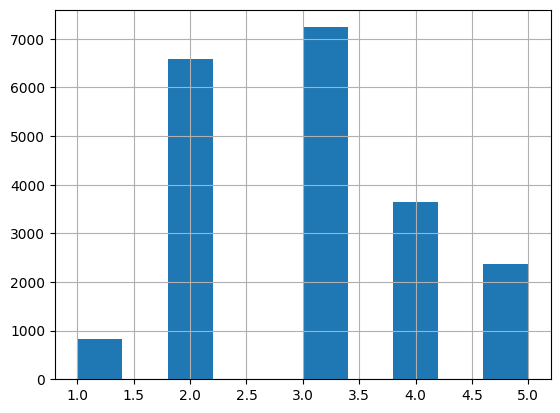

In [35]:
import numpy as np
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])
housing["income_cat"].hist()

- Splitting based on the income category

In [36]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

- Verify if it worked as expected

In [ ]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

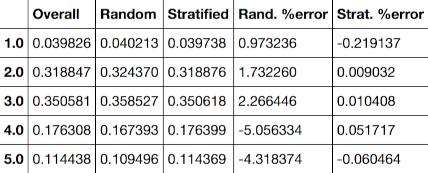
- stratified sampling is almost identical to those in the full dataset.
- purely random sampling is quite skewed.

Remove the income_cat attribute

In [39]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

# Explore the Data
Gain insights.
## Geographical Scatterplot

<AxesSubplot: xlabel='longitude', ylabel='latitude'>

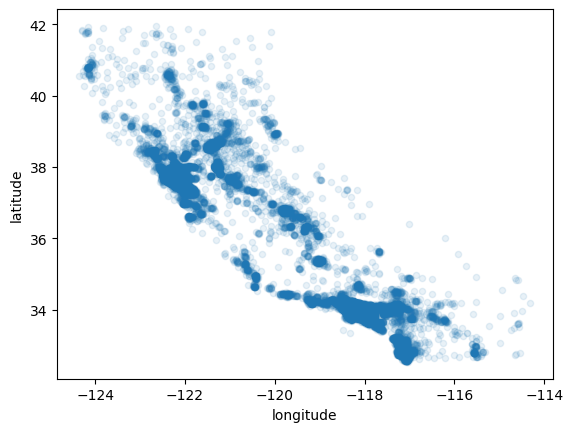

In [43]:
# create a copy so you can play with it without harming the training set
housing = strat_train_set.copy()
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1) # alpha=0.1: highlighting high-density areas

## Housing Price

- radius of each circle represents the district’s population (option s)
- the color represents the price (option c)
- use a predefined color map (option cmap) called jet, which ranges from blue to red

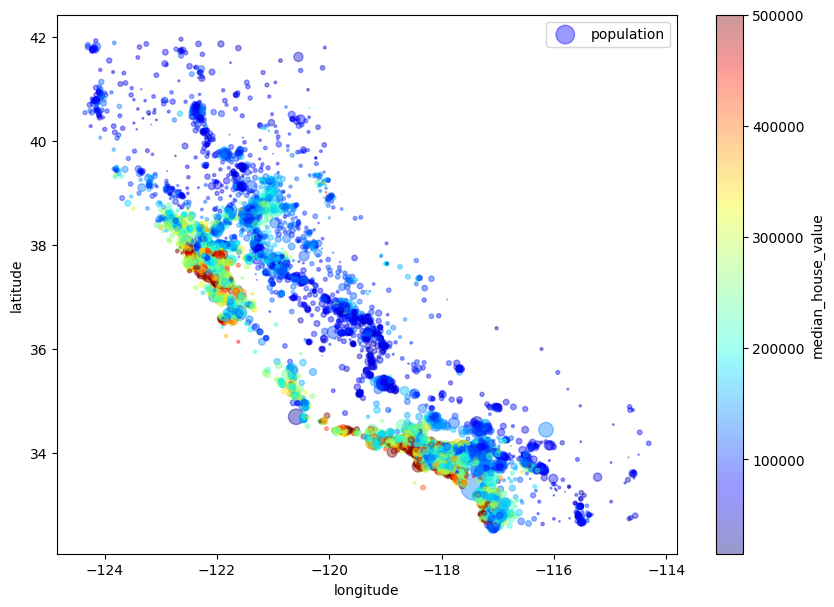

In [45]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True)
plt.legend()

## Correlation

The correlation coefficient only measures **linear** correlations

In [48]:
corr_matrix = housing.corr() # Pearson’s r
corr_matrix["median_house_value"].sort_values(ascending=False)

/tmp/ipykernel_14140/890734383.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr_matrix = housing.corr() # Pearson’s r


median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

Pandas'scatter_matrix function, which plots every numerical attribute against every other numerical attribute.

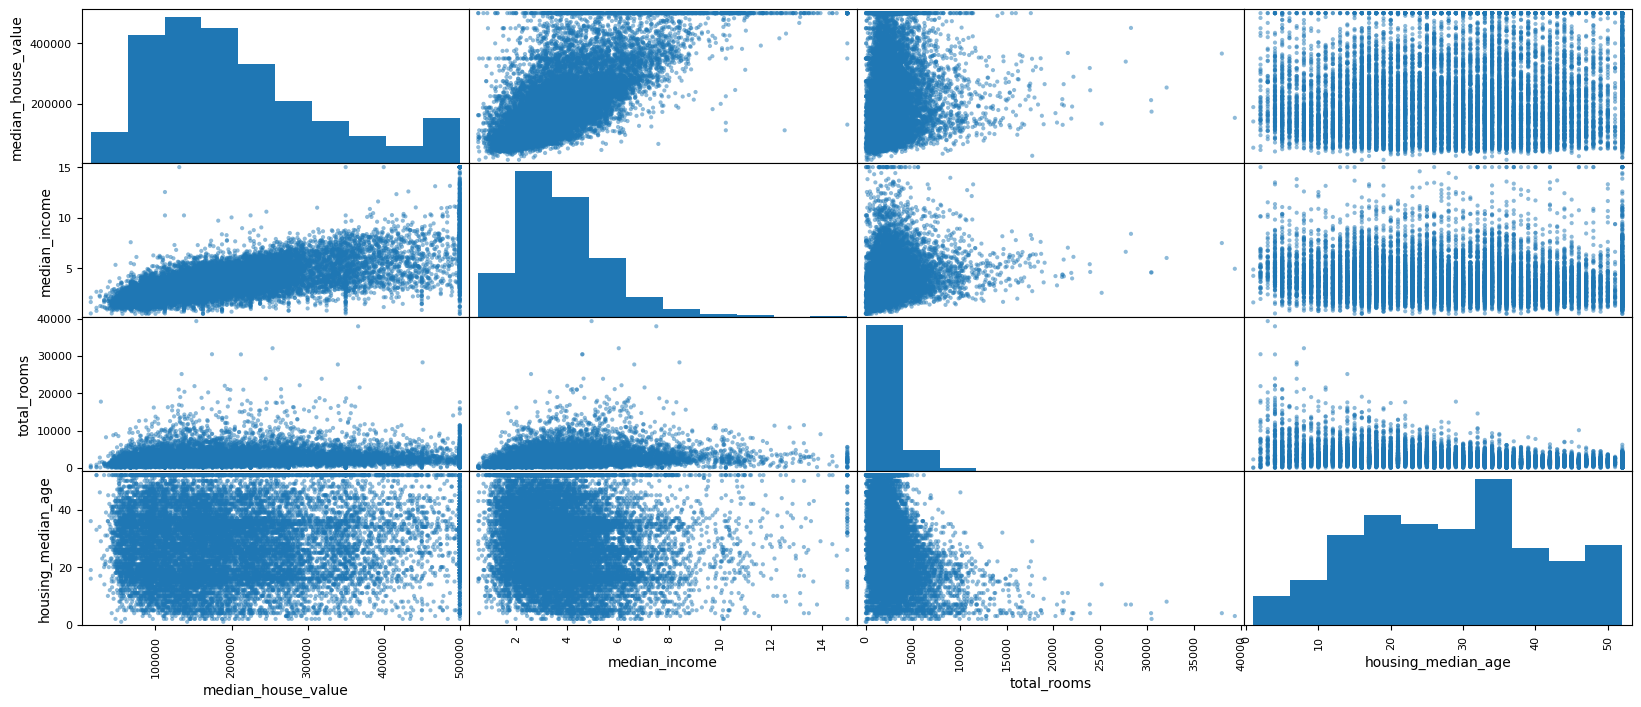

In [51]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
a = scatter_matrix(housing[attributes], figsize=(20, 8))

<AxesSubplot: xlabel='median_income', ylabel='median_house_value'>

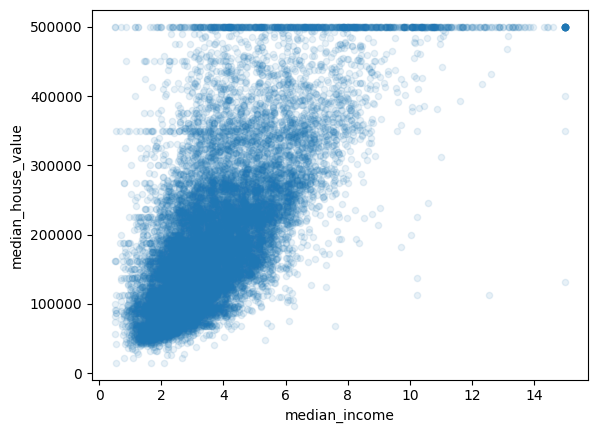

In [53]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)

- Try removing the corresponding districts(horizontallines) to prevent your algorithms from learning to reproduce these data quirks.

## Experimenting with Attribute Combinations
- may transform a tail-heavy distribution by computing their logarithm
- try out various attribute combinations
  - The total number of rooms in a district is not very useful. What you really want is the number of rooms per household.
  - The total number of bedrooms is not very useful. you probably want to compare it to the number of rooms.
  - The population per household also seems like an interesting attribute combination to look at.

In [55]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

corr_matrix = housing.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

- Apparently houses with a lower bedroom/room ratio tend to be more expensive.
- The number of rooms per household is also more informative than the total number of rooms in a district

# Prepare the Data

In [60]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

## Data Cleaning

### Fixing Missing Values
Options:

- Get rid of the corresponding districts. (row)
- Get rid of the whole attribute. (column)
- Set the values to some value (zero, the mean, the median, etc.).

In [61]:
# housing.dropna(subset=["total_bedrooms"]) # option 1
# housing.drop("total_bedrooms", axis=1) # option 2
median = housing["total_bedrooms"].median() # option 3
housing["total_bedrooms"].fillna(median, inplace=True)

Scikit-Learn Approach

In [68]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

# the median can only be computed on numerical attributes
# we need to create a copy of the data without the text attribute ocean_proximity
housing_num = housing.drop("ocean_proximity", axis=1)

# imputer.fit has simply computed the median of each attribute and stored the result
imputer.fit(housing_num)
imputer.statistics_ # result

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [70]:
# transform the training set by replacing missing values by the learned medians
X = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X, columns=housing_num.columns)
housing_tr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
1,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
3,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
4,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964


Handling Missing Text and Categorical Attributes

In [71]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)

,ocean_proximity
12655,INLAND
15502,NEAR OCEAN
2908,INLAND
14053,NEAR OCEAN
20496,<1H OCEAN
1481,NEAR BAY
18125,<1H OCEAN
5830,<1H OCEAN
17989,<1H OCEAN
4861,<1H OCEAN


Most Machine Learning algorithms prefer to work with numbers.

Let's convert these categories from text to numbers using Scikit-Learn's OrdinalEncoder

In [73]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [74]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

ML algorithms will assume that two nearby values are more similar than two distant values.
- To fix this issue, a common solution is to create one binary attribute per categoryfrom sklearn.preprocessing import OneHotEncoder
  - one attribute equal to 1 when the category is "<1H OCEAN" (and 0 otherwise)

In [78]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

In [80]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [79]:
housing_cat_1hot.toarray() # not necessary, just use the SciPy sparse matrix

array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

## Custom Transformers

You will want your transformer to work seamlessly with Scikit-Learn 
functionalities (such as pipelines), and since Scikit-Learn relies 
on duck typing.
- need to reate a class and implement three methods: `fit()`(returning self), `transform()`, and `fit_transform()`.
- You can get the `fit_transform()` for free by simply adding `TransformerMixin` as a base class.
- If you add BaseEstimator as a base class you will get `get_params()` and `set_params()` that will be useful for automatic hyperparameter tuning.

In [83]:
from sklearn.base import BaseEstimator, TransformerMixin

rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room = True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    
    def fit(self, X, y=None):
        return self # nothing else to do
    
    def transform(self, X, y=None):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)
housing_extra_attribs

array([[-121.46, 38.52, 29.0, ..., 'INLAND', 5.485835694050992,
        3.168555240793201],
       [-117.23, 33.09, 7.0, ..., 'NEAR OCEAN', 6.927083333333333,
        2.6236979166666665],
       [-119.04, 35.37, 44.0, ..., 'INLAND', 5.3933333333333335,
        2.223333333333333],
       ...,
       [-122.72, 38.44, 48.0, ..., '<1H OCEAN', 4.1104651162790695,
        2.6627906976744184],
       [-122.7, 38.31, 14.0, ..., '<1H OCEAN', 6.297405189620759,
        2.411177644710579],
       [-122.14, 39.97, 27.0, ..., 'INLAND', 5.477157360406092,
        3.1725888324873095]], dtype=object)

`add_bedrooms_per_room` hyperparameter will allow you to easily find out whether 
adding this attribute helps the Machine Learning algorithms or not.

More generally, you can add a hyperparameter to gate any data preparation step that you are not 100% sure about.

## Feature Scaling

Common ways:
- Min-max Scaling (Normalization)
- Standardization
  - Standardization is much less affected by outliers
  - Standardization does not bound values to a specific range
    - neural networks often expect an input value ranging from 0 to 1
    
Scikit-Learn transformer:
- MinMaxScaler
- StandardScaler

It is important to fit the scalers to the training data only, not to the full dataset

## Transformation Pipelines

All but the last estimator must be transformers. They must have a `fit_transform()` method.

In [85]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
])
housing_num_tr = num_pipeline.fit_transform(housing_num)

### Handling Categorical and Numerical Columns together

In [93]:
from sklearn.compose import ColumnTransformer

num_attribs = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
               'total_bedrooms', 'population', 'households', 'median_income']
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
    # ("to_drop", "drop", drop_attribs),
    # ("to_left", "passthrough", remaining_attribs)
])

housing_prepared = full_pipeline.fit_transform(housing)
housing_prepared

array([[-0.94135046,  1.34743822,  0.02756357, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.17178212, -1.19243966, -1.72201763, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.26758118, -0.1259716 ,  1.22045984, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.5707942 ,  1.31001828,  1.53856552, ...,  0.        ,
         0.        ,  0.        ],
       [-1.56080303,  1.2492109 , -1.1653327 , ...,  0.        ,
         0.        ,  0.        ],
       [-1.28105026,  2.02567448, -0.13148926, ...,  0.        ,
         0.        ,  0.        ]])

# Select and Train a Model
## Training on the Training Set

In [95]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

In [98]:
# try it out on the training set
some_data = housing.iloc[:5]
some_labels = housing_labels.iloc[:5]

some_data_prepared = full_pipeline.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))
print("Labels:", list(some_labels))

Predictions: [ 85657.90192014 305492.60737488 152056.46122456 186095.70946094
 244550.67966089]
Labels: [72100.0, 279600.0, 82700.0, 112500.0, 238300.0]


## Evaluating on the Training Set (Detecting Underfitting)

In [100]:
# Measure RMSE on the whole training set
from sklearn.metrics import mean_squared_error
housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

68627.87390018745

Underfitting! Possible causes:
- The features may not provide enough information to make good predictions
- The model is not powerful enough
- Too much regulation 

More complex model `DecisionTreeRegressor`

In [101]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()
tree_reg.fit(housing_prepared, housing_labels)

DecisionTreeRegressor()

In [102]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

0.0

## Evaluation Using Cross-Validation
- Split the training set into a smaller training set and a validation set
  - A great alternative is to use Scikit-Learn's K-fold cross-validation feature.
  
The following code randomly splits the training set into 10 distinct subsets called folds, 
then it trains and evaluates the Decision Tree model 10 times, picking a different fold for
evaluation every time and training on the other 9 folds. The result is an array containing 
the 10 evaluation scores
- Scikit-Learn's cross-validation features expect a utility function(greater is better) rather than a cost function (lower is better). e.g. `neg_mean_squared_error`

In [110]:
from sklearn.model_selection import cross_val_score
# decision tree
scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [109]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())
display_scores(tree_rmse_scores)

Scores: [73096.9603068  71489.60345461 68166.20067011 70347.98006347
 70570.73837475 76376.14465033 69746.12954217 73569.27546848
 67202.65453491 71098.81738619]
Mean: 71166.45044518034
Standard deviation: 2539.795406386351


In [112]:
# linear regression
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [71762.76364394 64114.99166359 67771.17124356 68635.19072082
 66846.14089488 72528.03725385 73997.08050233 68802.33629334
 66443.28836884 70139.79923956]
Mean: 69104.07998247063
Standard deviation: 2880.328209818062


The Decision Tree model is overfitting so badly that it performs worse than the Linear Regression model.

In [117]:
from sklearn.ensemble import RandomForestRegressor
# random forest
forest_reg = RandomForestRegressor()
forest_reg.fit(housing_prepared, housing_labels)

RandomForestRegressor()

In [118]:
forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

Scores: [51612.32901162 49056.59610489 46923.37718046 52169.39674122
 47665.75859236 51417.24991348 52559.42705329 49771.60410191
 48516.97339674 53691.87744358]
Mean: 50338.45895395455
Standard deviation: 2154.1912651540365


Much better! The goal is to shortlist a few(two to five) promising models.

In [ ]:
# Save models
# from sklearn.externals import joblib
# joblib.dump(my_model, "my_model.pkl")
# my_model_loaded = joblib.load("my_model.pkl")

# Fine-Tune Your Model